In [3]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import datetime as dt
import json

## Load Data
Indicate attention broker IDs (anonymous integer IDs from the Smith et al. "A Blue Start" dataset) and load JSON blobs of repost & original post timing data.

In [4]:

ab_ids = {4928, 24513, 295, 69545, 2713, 4947, 213, 4508, 284, 3838}

In [5]:
rpl_data = json.load(open('./repost_intervals_by_acct_id.json'))
org_data = json.load(open('./original_posts_by_acct_id.json'))
combined_post_timings = {k: sorted(rpl_data.get(k, {'repost-created-at': []})['repost-created-at'] + org_data[k]) for k in org_data.keys()}

## Analyze + Plot Repost Latency Relative to Content Creation Time
We use a [Mann-Whitney U Test](https://projecteuclid.org/journals/annals-of-mathematical-statistics/volume-18/issue-1/On-a-Test-of-Whether-one-of-Two-Random-Variables/10.1214/aoms/1177730491.full) to determine whether attention brokers' repost latencies are different from non-attention brokers' using a variety of approaches.

In [6]:
def analyze_latencies(
    func_to_use, 
    id_to_latencies, 
    title, 
    ylabel='Proportion of Accounts', 
    mwu_dir='greater', 
    set_axes_01=True
):
    """
    Analyze + plot post/repost latency information with a given analysis function.

    Inputs:
      func_to_use: callable; indicates how the latencies will be aggregated/analyzed.
      id_to_latencies: maps account IDs from the "A Blue Start" dataset to repost timing data for that account.
      title: title for the violin plot
      ylabel: label for the violin plot's y-axis; default = Proportion of Accounts
      mwu_dir: direction for the Mann-Whitney U Test (either greater or less)
      set_axes_01: whether to set the y-axis range betweeen [0, 1.0]. default = True

    Outputs:
      Doesn't return anything; displays a violin plot and prints out the result of the Mann-Whitney U Test
    """
    ab_stats = []
    non_stats = []
    for acct_id, latencies in id_to_latencies.items():
        if int(acct_id) in ab_ids:
            ab_stats.append(func_to_use(latencies))
        else:
            non_stats.append(func_to_use(latencies))
            
    plt.rcParams['figure.figsize'] = (8, 8)
    plt.violinplot(
        [ab_stats, non_stats],
        [1, 2], 
        showmeans=True,
        showextrema=True,
        facecolor=['xkcd:aqua', 'xkcd:lightblue'],
        linecolor='black',
    )
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks([1, 2], [f'Attention Brokers\nn={len(ab_stats)}', f'Non-Attention Brokers\nn={len(non_stats)}'])
    if set_axes_01:
        plt.ylim(0.0, 1.0)
    ab_stats = np.array(ab_stats)[~np.isnan(np.array(ab_stats))]
    non_stats = np.array(non_stats)[~np.isnan(np.array(non_stats))]

    print(mannwhitneyu(ab_stats, non_stats, method='exact', alternative=mwu_dir))
    plt.savefig(f'./new_figs/{title}.pdf')


### Analyzing Proportion of Low-Latency Reposts

MannwhitneyuResult(statistic=np.float64(443.0), pvalue=np.float64(0.001328690460103184))


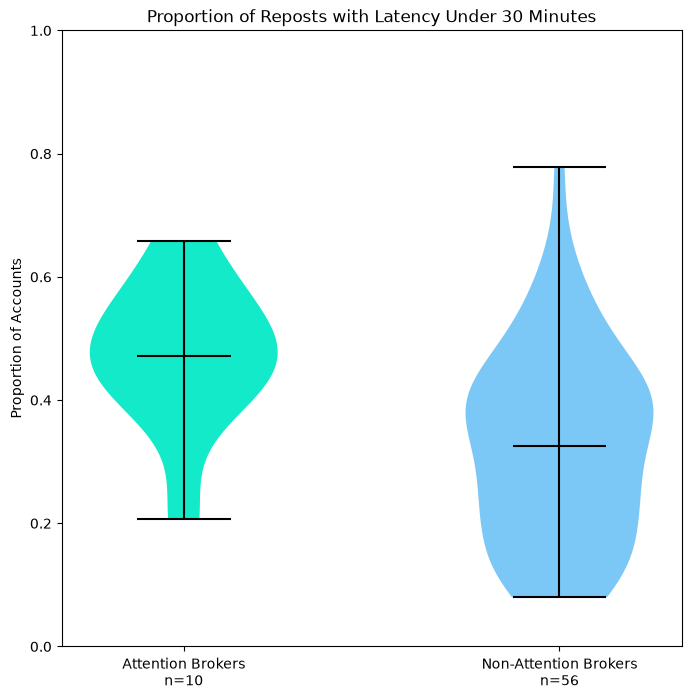

In [7]:
def get_proportion_below_cutoff_hrs(latencies, cutoff_hrs):
    # Get the proportion of repost latencies that occurred below a certain cutoff (in hours).
    return np.mean([l < cutoff_hrs for l in latencies['hours_between_op_and_repost']])

analyze_latencies(
    lambda b: get_proportion_below_cutoff_hrs(b, 0.5), 
    rpl_data, 
    'Proportion of Reposts with Latency Under 30 Minutes', 
    mwu_dir='greater'
)

MannwhitneyuResult(statistic=np.float64(415.0), pvalue=np.float64(0.007254215640945759))


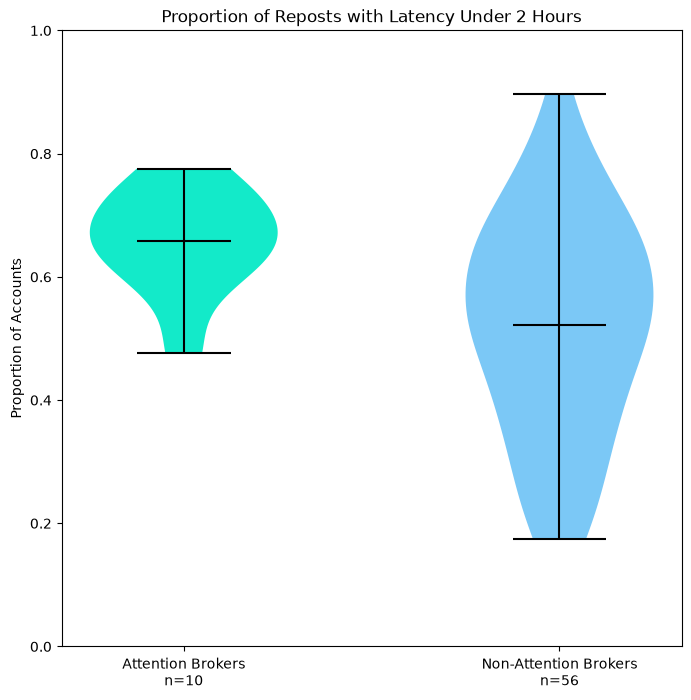

In [8]:
analyze_latencies(
    lambda b: get_proportion_below_cutoff_hrs(b, 2), 
    rpl_data, 
    'Proportion of Reposts with Latency Under 2 Hours', 
    mwu_dir='greater'
)

MannwhitneyuResult(statistic=np.float64(397.0), pvalue=np.float64(0.01790101097555012))


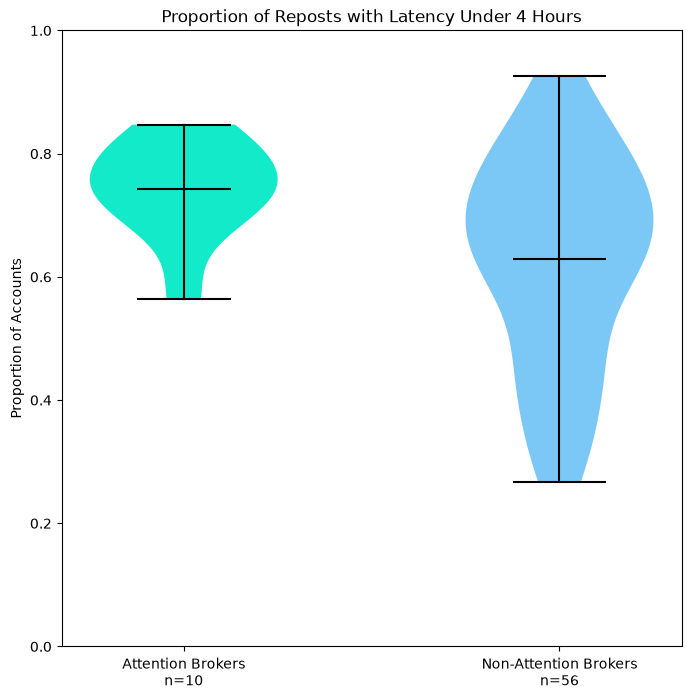

In [9]:
analyze_latencies(
    lambda b: get_proportion_below_cutoff_hrs(b, 4), 
    rpl_data, 
    'Proportion of Reposts with Latency Under 4 Hours', 
    mwu_dir='greater'
)

MannwhitneyuResult(statistic=np.float64(376.0), pvalue=np.float64(0.0439054663653741))


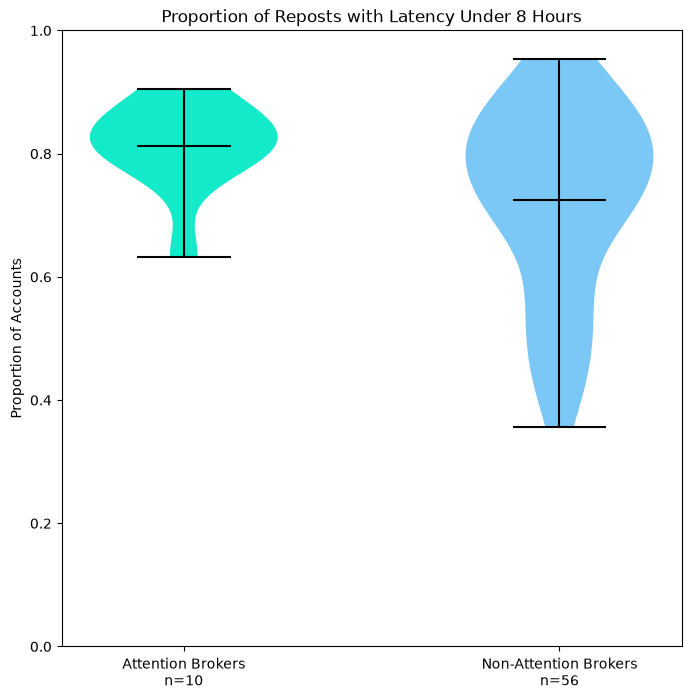

In [10]:
analyze_latencies(
    lambda b: get_proportion_below_cutoff_hrs(b, 8), 
    rpl_data, 
    'Proportion of Reposts with Latency Under 8 Hours', 
    mwu_dir='greater'
)

MannwhitneyuResult(statistic=np.float64(360.0), pvalue=np.float64(0.0786480073129453))


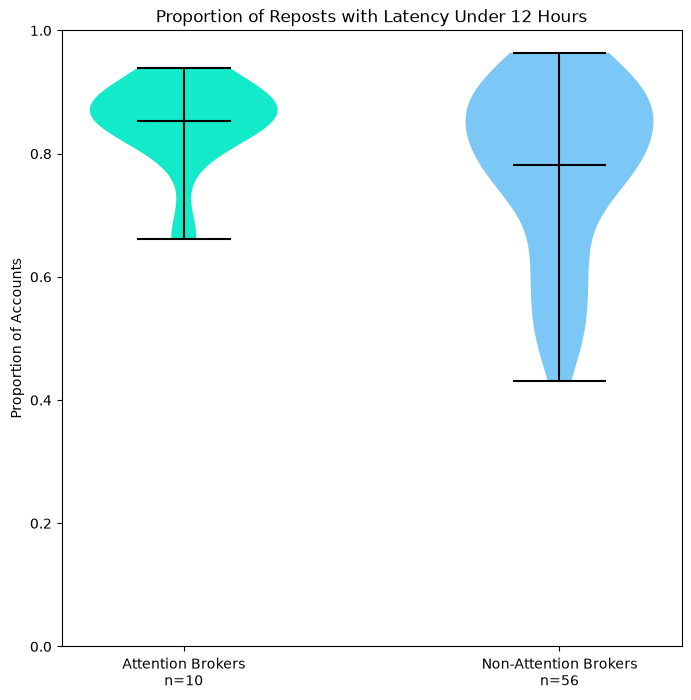

In [11]:
analyze_latencies(
    lambda b: get_proportion_below_cutoff_hrs(b, 12), 
    rpl_data, 
    'Proportion of Reposts with Latency Under 12 Hours', 
    mwu_dir='greater'
)

### Analyzing Mean, Median, + Standard Deviation of Latencies

MannwhitneyuResult(statistic=np.float64(275.0), pvalue=np.float64(0.4684252577215902))


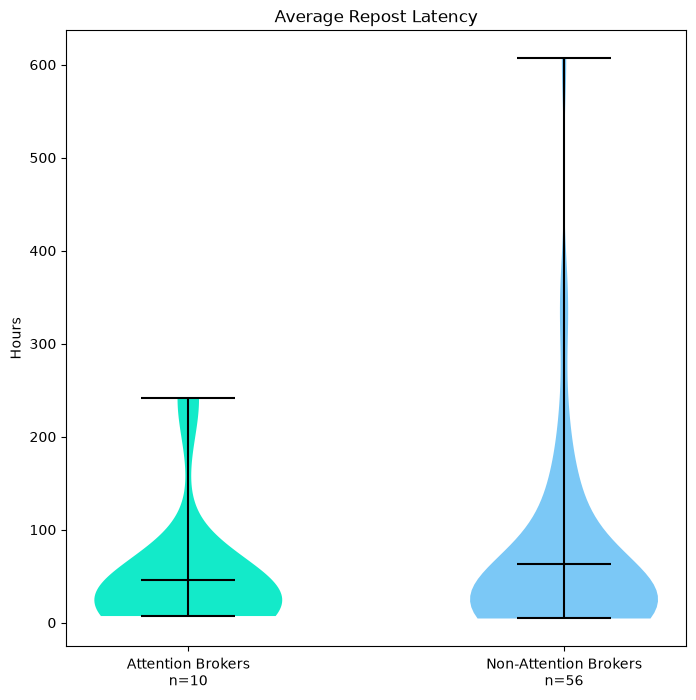

In [12]:
analyze_latencies(
    lambda b: np.mean(b['hours_between_op_and_repost']), 
    rpl_data, 
    'Average Repost Latency', 
    ylabel='Hours', 
    mwu_dir='less', 
    set_axes_01=False
)

MannwhitneyuResult(statistic=np.float64(324.0), pvalue=np.float64(0.7840503914174454))


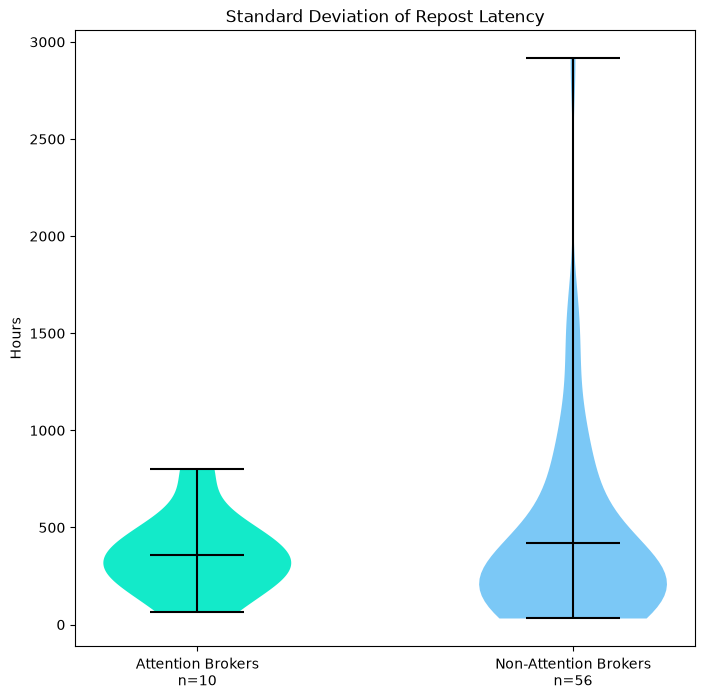

In [13]:
analyze_latencies(
    lambda b: np.std(b['hours_between_op_and_repost']), 
    rpl_data, 
    'Standard Deviation of Repost Latency', 
    ylabel='Hours', 
    mwu_dir='less', 
    set_axes_01=False
)

MannwhitneyuResult(statistic=np.float64(117.0), pvalue=np.float64(0.001328690460103184))


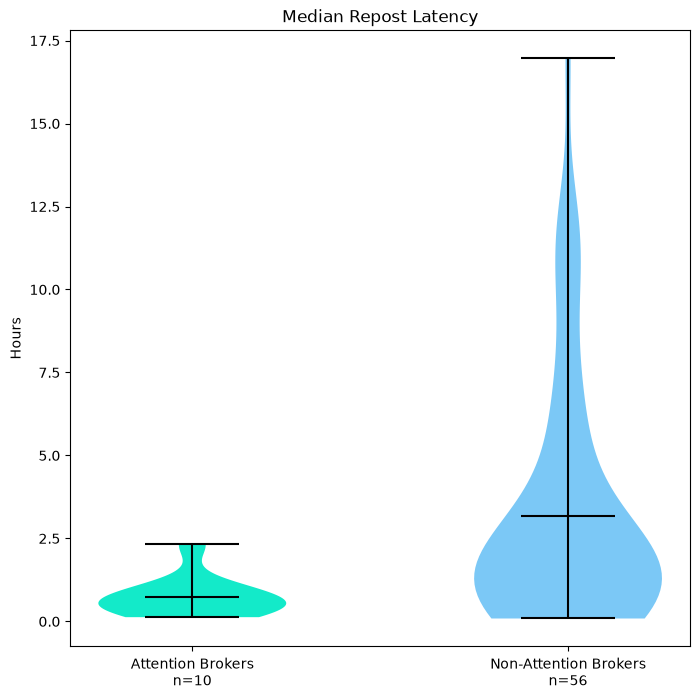

In [14]:
analyze_latencies(
    lambda b: np.median(b['hours_between_op_and_repost']), 
    rpl_data, 
    'Median Repost Latency', 
    ylabel='Hours', 
    mwu_dir='less', 
    set_axes_01=False
)

### Obtaining Inter-Repost Intervals
We obtain both global inter-repost intervals (on average, how soon after the previous repost does the next repost occur) as well as the maximum daily inter-repost intervals (on average, how long is the longest break between an account's reposts each day?). Then we take the {average, mediam, standard deviation} of the overall inter-repost intervals as well as the average of the maximum daily inter-repost intervals for each account and compare them using the same procedure as before. We do not see any significant differences with this approach.

In [15]:
avg_max_per_day_repost_interval = {}
avg_repost_interval = {}
std_repost_interval = {}
median_repost_interval = {}

for k, d in rpl_data.items():
    repost_created_at = pd.to_datetime(sorted(d['repost-created-at']))
    day_created_at = repost_created_at.floor('D')
    df = pd.DataFrame({'repost-created-at': repost_created_at, 'day-created-at': day_created_at})
    avg_repost_interval[k] = df['repost-created-at'].diff().mean()
    std_repost_interval[k] = df['repost-created-at'].diff().std()
    median_repost_interval[k] = df['repost-created-at'].diff().median()
    avg_max_per_day_repost_interval[k] = np.mean(
        [
            gr.diff().max() 
            for _, gr in df.groupby('day-created-at')['repost-created-at'] 
            if gr.diff().max() > dt.timedelta(days=0)
        ]
    )
    
    

MannwhitneyuResult(statistic=np.float64(294.0), pvalue=np.float64(0.6007813722678171))


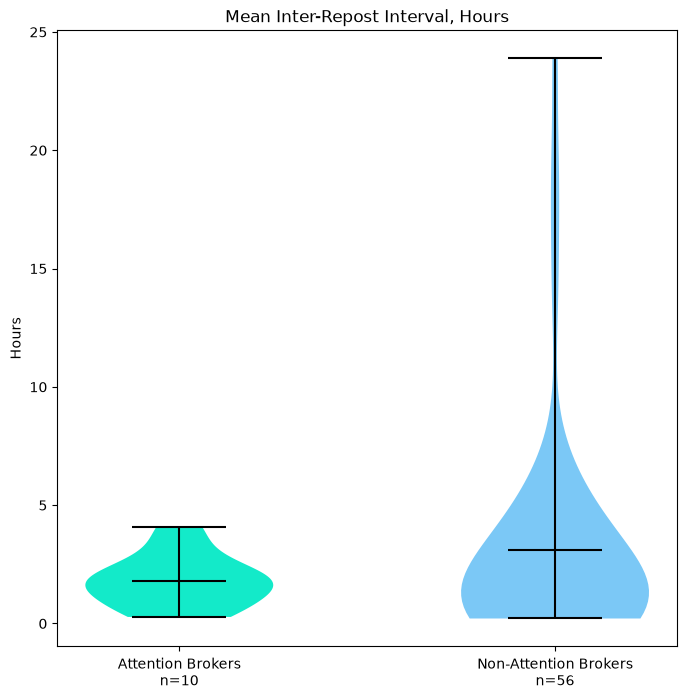

In [16]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    avg_repost_interval, 
    'Mean Inter-Repost Interval, Hours', 
    ylabel='Hours', 
    mwu_dir='less', 
    set_axes_01=False
)

MannwhitneyuResult(statistic=np.float64(270.0), pvalue=np.float64(0.43357501451385666))


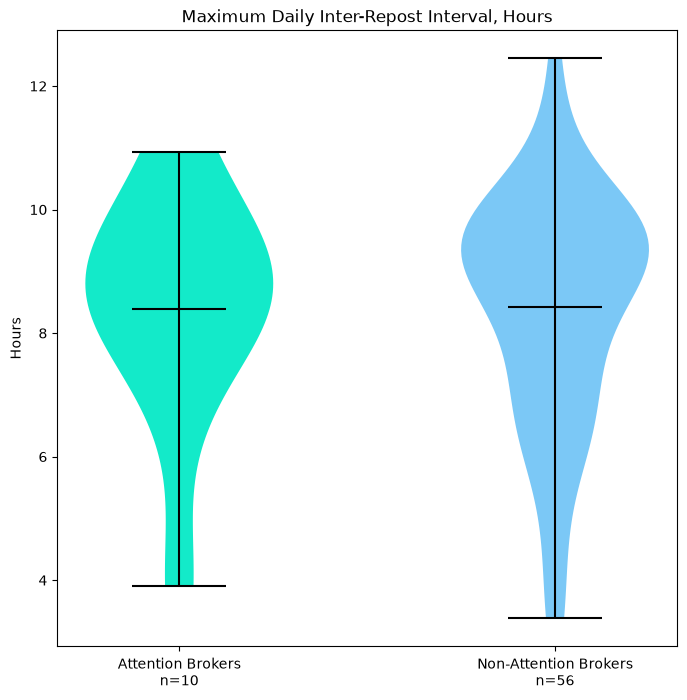

In [17]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    avg_max_per_day_repost_interval, 
    'Maximum Daily Inter-Repost Interval, Hours', 
    ylabel='Hours',
    mwu_dir='less', 
    set_axes_01=False
)

MannwhitneyuResult(statistic=np.float64(277.0), pvalue=np.float64(0.48244617832353465))


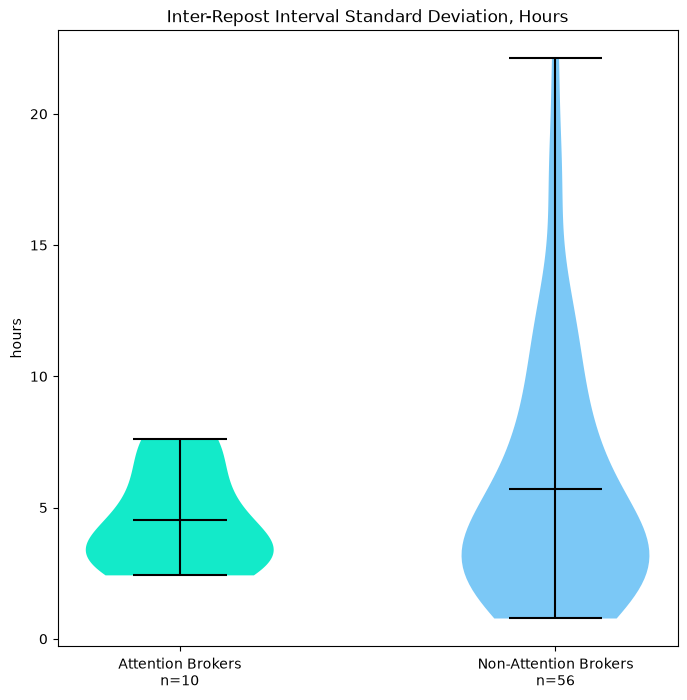

In [18]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    std_repost_interval, 
    'Inter-Repost Interval Standard Deviation, Hours', 
    ylabel='hours', 
    mwu_dir='less', 
    set_axes_01=False
)

### Obtaining Inter-{Post, Reply, Repost} Intervals
We obtain both global inter-post intervals (on average, how soon after the previous act of content creation/amplification (for which we count a reply, a repost, or an original post) does the next one occur?) as well as the maximum daily inter-post intervals (on average, how long is the longest break between an account's posts each day?). Then we take the {average, mediam, standard deviation} of the overall inter-post intervals as well as the average of the maximum daily inter-post intervals for each account and compare them using the same procedure as before. We do not see any significant differences with this approach.

In [19]:
avg_max_per_day_posting_interval = {}
avg_posting_interval = {}
std_posting_interval = {}
median_posting_interval = {}

for k, d in combined_post_timings.items():
    post_created_at = pd.to_datetime(sorted(d), format='mixed')
    day_created_at = post_created_at.floor('D')
    df = pd.DataFrame({'created-at': post_created_at, 'day-created-at': day_created_at})
    avg_posting_interval[k] = df['created-at'].diff().mean()
    std_posting_interval[k] = df['created-at'].diff().std()
    median_posting_interval[k] = df['created-at'].diff().median()
    if len(df) > 0:
        avg_max_per_day_posting_interval[k] = np.mean(
            [
                gr.diff().max()
                for _, gr in df.groupby('day-created-at')['created-at'] 
                if gr.diff().max() > dt.timedelta(days=0) 
            ]
        )
    
    

MannwhitneyuResult(statistic=np.float64(379.0), pvalue=np.float64(0.3321675956802178))


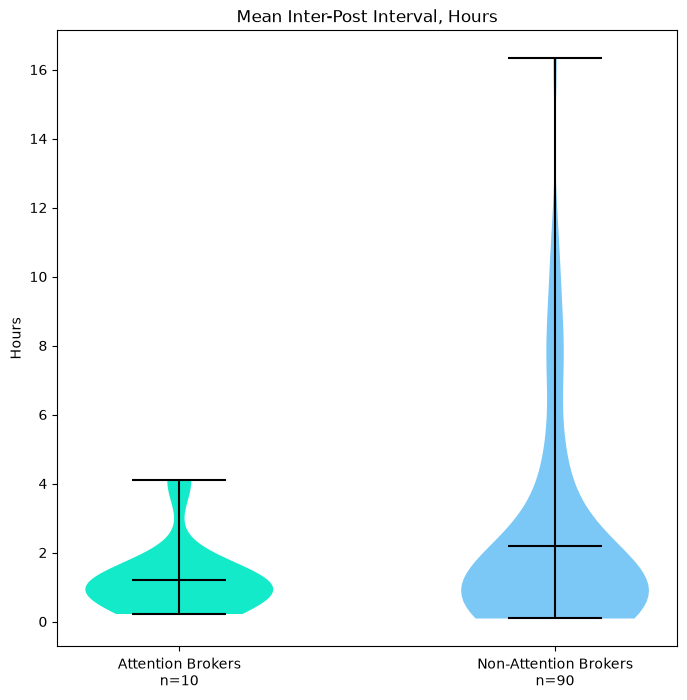

In [20]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    avg_posting_interval, 
    'Mean Inter-Post Interval, Hours', 
    ylabel='Hours', 
    mwu_dir='less', 
    set_axes_01=False,
)

MannwhitneyuResult(statistic=np.float64(499.0), pvalue=np.float64(0.8502608542988046))


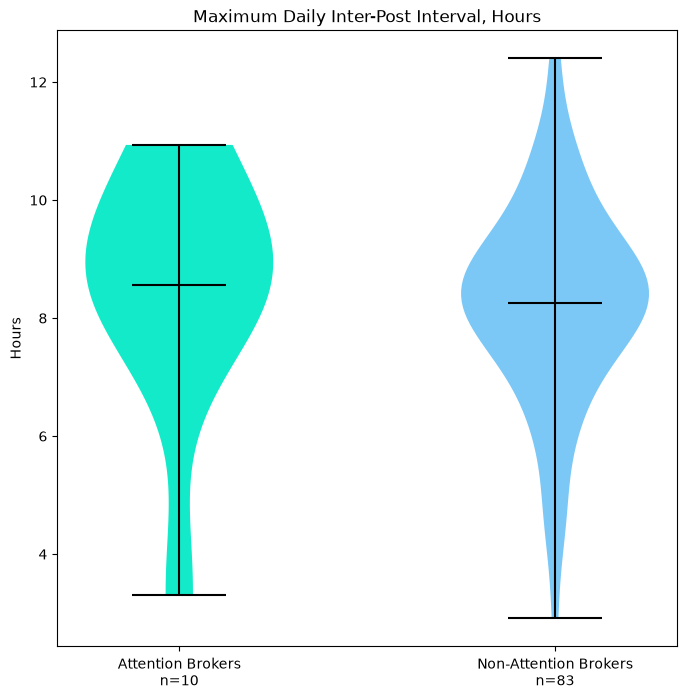

In [21]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    avg_max_per_day_posting_interval, 
    'Maximum Daily Inter-Post Interval, Hours', 
    ylabel='Hours',
    mwu_dir='less', 
    set_axes_01=False
)

MannwhitneyuResult(statistic=np.float64(359.0), pvalue=np.float64(0.2484601635178179))


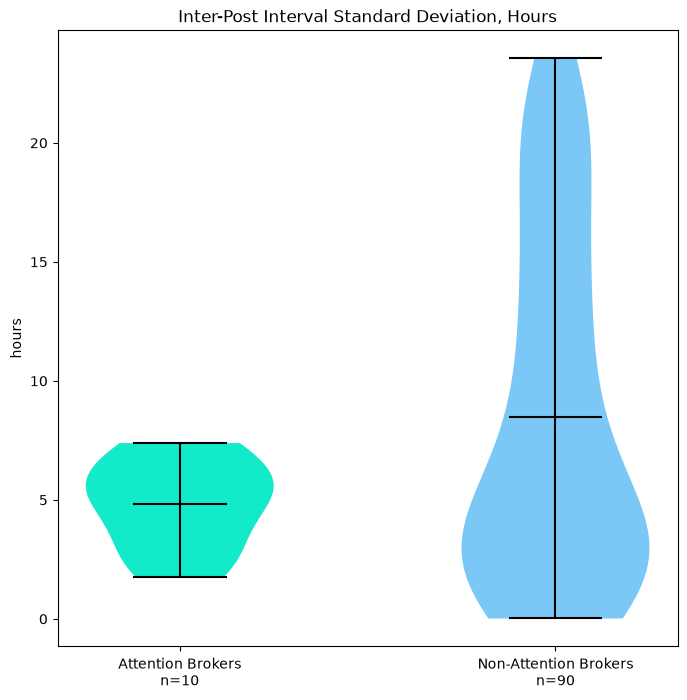

In [22]:
analyze_latencies(
    lambda b: b.seconds / (60 * 60), 
    std_posting_interval, 
    'Inter-Post Interval Standard Deviation, Hours', 
    ylabel='hours', 
    mwu_dir='less', 
    set_axes_01=False
)

## Repost Intervals for Case Study
We can use Acct 295's entry in our JSON repost latency blob to construct a histogram of repost latencies for our case study.

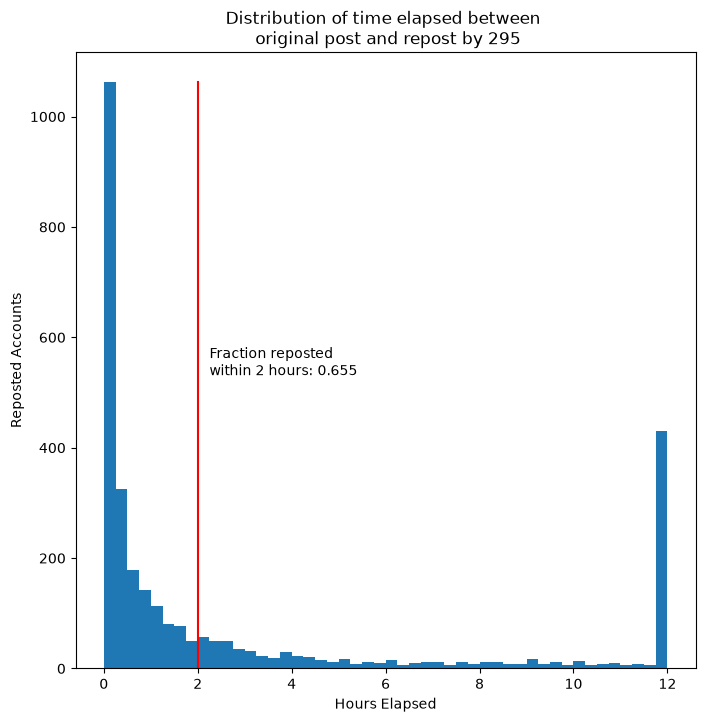

In [23]:
def plot_latencies(acct, latencies):
    counts, bins = np.histogram(latencies, bins=[0.25 * i for i in range(48)] + [100000])
    plt.bar(bins[:-1], counts, width=[0.25 for i in counts], align='edge')
    plt.title(f'Distribution of time elapsed between \n original post and repost by {acct}')
    plt.xlabel('Hours Elapsed')
    plt.ylabel('Reposted Accounts')
    plt.text(2.25, 0.5 * max(counts), f'Fraction reposted \nwithin 2 hours: {np.mean([l < 2 for l in latencies]):.3f}')
    plt.plot([2, 2], [0, max(counts)], color='red') # may have to adjust height of red line
    plt.savefig(f'./new_figs/{acct}_time_between_op_and_repost.pdf')

plot_latencies(295, [float(i) for i in rpl_data['295']['hours_between_op_and_repost']])